Install dependencies and import libraries

In [ ]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

In [ ]:
!pip install kaggle

!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone --unzip -p ./ct_kidney

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
100% 1.52G/1.52G [00:14<00:00, 112MB/s] 



Load images and labels into DataFrame

In [ ]:
# Path to downloaded dataset
dataset_dir = "./ct_kidney"

# Get all image file paths
image_paths = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)

# Extract labels from folder names
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

# Create DataFrame
df = pd.DataFrame({"image_path": image_paths, "label": labels})
print("Total images:", len(df))
print(df.head())

Total images: 12446
                                          image_path label
0  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
1  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
2  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
3  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst
4  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Cyst


In [ ]:
print(df['label'].value_counts())
class_counts = df['label'].value_counts()

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

label
Normal    5077
Cyst      3709
Tumor     2283
Stone     1377
Name: count, dtype: int64
Normal: 5077
Cyst: 3709
Tumor: 2283
Stone: 1377


Encode labels and split dataset

In [ ]:
# Encode string labels to integers
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Split into train, val, test (80-10-10)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_enc'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df['label_enc'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 8960, Val: 996, Test: 2490


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255

)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8960 validated image filenames belonging to 4 classes.
Found 996 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


In [ ]:
def build_baseline_model():
    model = Sequential([
        Input(shape=(224,224,3)),

        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
baseline_model = build_baseline_model()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - accuracy: 0.9213 - loss: 0.2296 - val_accuracy: 0.9990 - val_loss: 0.0063
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.9942 - loss: 0.0172 - val_accuracy: 0.9990 - val_loss: 0.0034
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9969 - loss: 0.0089 - val_accuracy: 0.9980 - val_loss: 0.0104
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.9968 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 4.2547e-05
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.9980 - loss: 0.0069 - val_accuracy: 0.9990 - val_loss: 0.0020
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.9956 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 8.0762e-04
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 39s 69ms/step - accuracy: 0.9981 - loss: 0

In [ ]:
loss, acc = baseline_model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9996 - loss: 0.0089
Test Accuracy: 99.96%


In [ ]:
print(history_baseline.history['accuracy'][-1])
print(history_baseline.history['val_accuracy'][-1])

0.9975446462631226
1.0


156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step


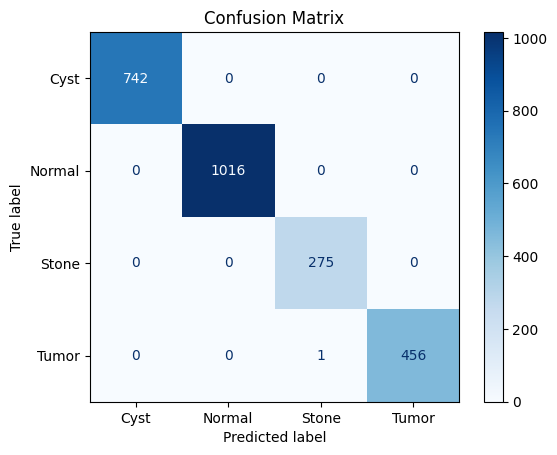

In [ ]:
# 1. Confusion Matrix
# Get predictions
y_pred = baseline_model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes  # true labels from generator

# Display confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

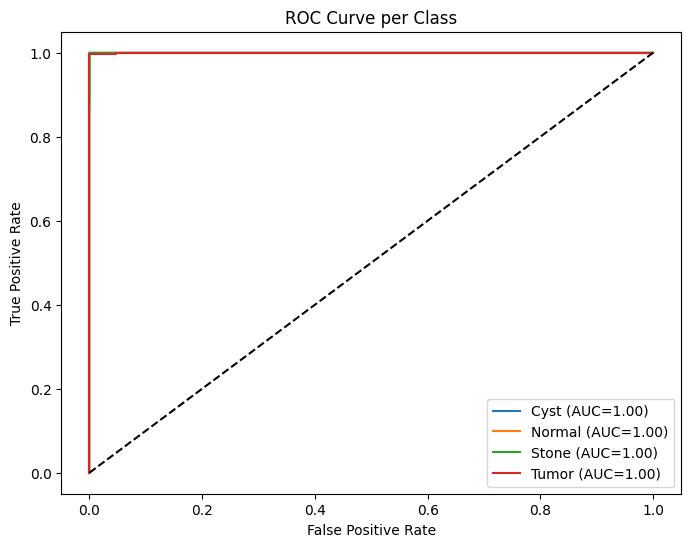

In [ ]:
# --- 2. ROC Curves for Each Class ---
from sklearn.preprocessing import label_binarize

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(len(test_gen.class_indices))))
plt.figure(figsize=(8,6))

for i, class_name in enumerate(test_gen.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()







1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


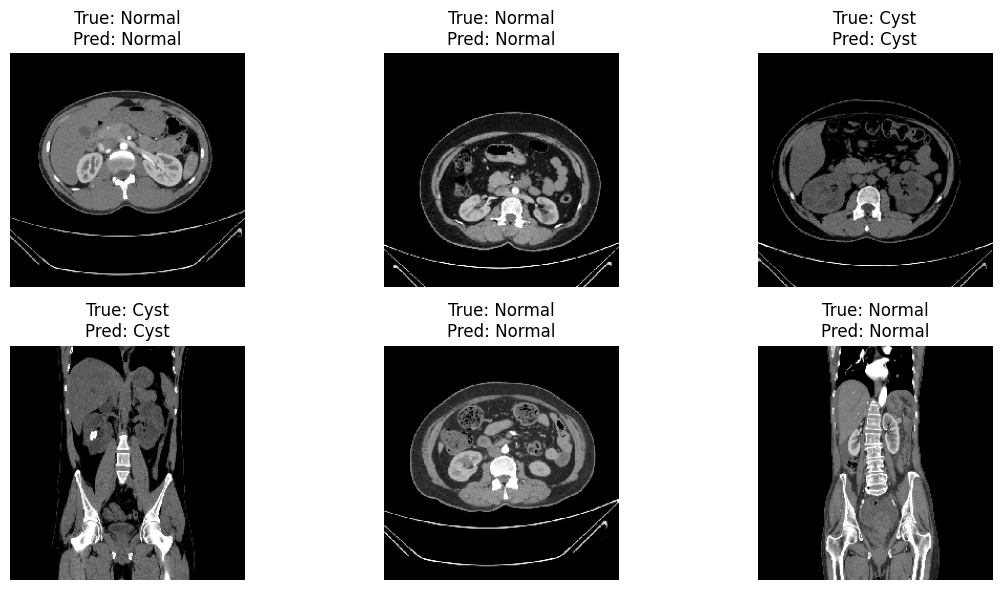

In [ ]:
# --- 3. Sample Predictions ---
import matplotlib.pyplot as plt

# Get some sample images from the generator
test_images, test_labels = next(test_gen)  # first batch
pred_classes = np.argmax(baseline_model.predict(test_images), axis=1)
true_classes = np.argmax(test_labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {list(test_gen.class_indices.keys())[true_classes[i]]}\nPred: {list(test_gen.class_indices.keys())[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

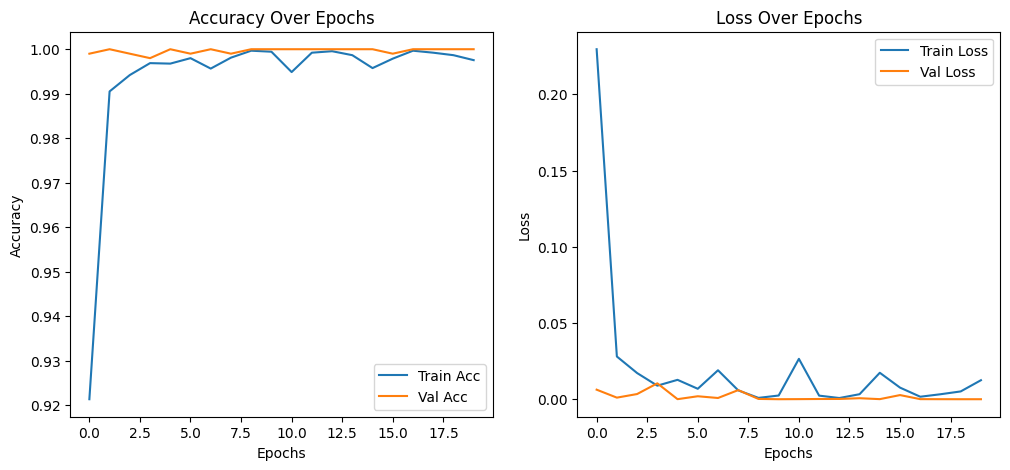

In [ ]:
# --- 4. Training Curves (Accuracy & Loss) ---
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_baseline.history['accuracy'], label='Train Acc')
plt.plot(history_baseline.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Loss
plt.subplot(1,2,2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()